In [ ]:

import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys
from mne.time_frequency import tfr_morlet
from pathlib import Path
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds


epoch_path = "E:/workspace/kiki_conformity_data/Trust_Clean2" # 分析哪个roi就输入哪个文件夹的数据
behavior_path = "E:/workspace/kiki_conformity_data/imagelevel" # 分析哪个roi就输入哪个文件夹的数据

subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

len(subjects)
str_subjects = [str(arr) for arr in subjects]

freqs=np.arange(4, 8, 1)
# # freqs=np.arange(8, 13, 1)
# # freqs=np.arange(13, 30, 1)

# # n_cycles = 10
n_cycles = freqs/4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:  # 2
        n_cycles[i] = 2 # 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10

# freqs=np.arange(4, 31, 1) # 4 5 6 7     8 9 10 11 12 13
# n_cycles = np.linspace(2, 5, num=27)
# freqs = freqs[0:4]  # theta
# n_cycles = n_cycles[0:4]
# freqs = freqs[4:10]  # Alpha
# n_cycles = n_cycles[4:10]
# freqs = freqs[10:]  # Beta
# n_cycles = n_cycles[10:]


image_type = 8

In [91]:
import pandas as pd
from pathlib import Path
import numpy as np


all_sub_higher_in_task3 = {}
all_sub_lower_in_task3 = {}

for i in range(len(subjects)):
    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/imagelevel")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}_imagelevel.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # print(f"Subject {subjects[i]}: {len(behavior_trial)} rows loaded")

    # 筛选task2和task4的数据
    task2_df = behavior_trial[behavior_trial['image_type'] == (200 + image_type)]
    task4_df = behavior_trial[behavior_trial['image_type'] == (400 + image_type)]
    
    # 筛选task3的数据
    task3_df = behavior_trial[behavior_trial['image_type'] == 300 + image_type]  # 假设task3的image_type是309
    
    # 调整task3的rating
    task3_df = task3_df.copy()  # 避免SettingWithCopyWarning
    task3_df['rating_adjusted'] = task3_df['rating'] - 30
    
    # 计算grouprating和调整后rating的差值
    task3_df['difference'] = task3_df['grouprating'] - task3_df['rating_adjusted']
    
    # 分为higher和lower两组
    higher_in_task3 = task3_df[task3_df['difference'] > 0]  # grouprating更高的图片
    lower_in_task3 = task3_df[task3_df['difference'] < 0]   # grouprating更低的图片
    
    # 初始化存储结果
    higher_in_task4 = []
    lower_in_task4 = []
    
    # 处理higher组
    for _, row in higher_in_task3.iterrows():
        image_name = row['ImageName']
        
        # 在task2中查找对应的图片
        task2_row = task2_df[task2_df['ImageName'] == image_name]
        # 在task4中查找对应的图片
        task4_row = task4_df[task4_df['ImageName'] == image_name]
        
        if not task2_row.empty and not task4_row.empty:
            higher_in_task4.append((task2_row.index[0], task4_row.index[0]))
    
    # 处理lower组
    for _, row in lower_in_task3.iterrows():
        image_name = row['ImageName']
        
        # 在task2中查找对应的图片
        task2_row = task2_df[task2_df['ImageName'] == image_name]
        # 在task4中查找对应的图片
        task4_row = task4_df[task4_df['ImageName'] == image_name]
        
        if not task2_row.empty and not task4_row.empty:
            lower_in_task4.append((task2_row.index[0], task4_row.index[0]))
    
    # 存储结果
    all_sub_higher_in_task3[subjects[i]] = np.array(higher_in_task4) if higher_in_task4 else np.array([])
    all_sub_lower_in_task3[subjects[i]] = np.array(lower_in_task4) if lower_in_task4 else np.array([])
    
    print(f"Subject {subjects[i]} - Higher: {len(higher_in_task4)}, Lower: {len(lower_in_task4)}")

# 检查哪些被试的数据为空
empty_higher = [sub for sub in subjects if len(all_sub_higher_in_task3.get(sub, [])) == 0]
empty_lower = [sub for sub in subjects if len(all_sub_lower_in_task3.get(sub, [])) == 0]

# print("\n检查结果:")
# if empty_higher:
#     print(f"以下被试的higher_in_task4为空: {empty_higher}")
# else:
#     print("所有被试的higher_in_task4都有数据")

# if empty_lower:
#     print(f"以下被试的lower_in_task4为空: {empty_lower}")
# else:
#     print("所有被试的lower_in_task4都有数据")

# 更新有效的subjects列表
valid_subjects = [sub for sub in subjects 
                 if len(all_sub_higher_in_task3.get(sub, [])) > 0 
                 and len(all_sub_lower_in_task3.get(sub, [])) > 0]

# print(f"\n有效的被试列表(两者都非空): {valid_subjects}")
# print(f"有效被试数量: {len(valid_subjects)}")

subjects = valid_subjects

Subject 2 - Higher: 7, Lower: 6
Subject 3 - Higher: 3, Lower: 1
Subject 4 - Higher: 4, Lower: 3
Subject 5 - Higher: 6, Lower: 14
Subject 6 - Higher: 7, Lower: 7
Subject 7 - Higher: 1, Lower: 3
Subject 8 - Higher: 0, Lower: 11
Subject 9 - Higher: 0, Lower: 19
Subject 10 - Higher: 19, Lower: 0
Subject 11 - Higher: 2, Lower: 17
Subject 12 - Higher: 3, Lower: 11
Subject 13 - Higher: 1, Lower: 9
Subject 14 - Higher: 7, Lower: 12
Subject 15 - Higher: 0, Lower: 13
Subject 16 - Higher: 4, Lower: 5
Subject 17 - Higher: 3, Lower: 2
Subject 18 - Higher: 1, Lower: 4
Subject 19 - Higher: 1, Lower: 0
Subject 20 - Higher: 13, Lower: 2
Subject 21 - Higher: 1, Lower: 6
Subject 22 - Higher: 0, Lower: 2
Subject 23 - Higher: 1, Lower: 6
Subject 24 - Higher: 12, Lower: 5
Subject 25 - Higher: 8, Lower: 0
Subject 26 - Higher: 3, Lower: 11
Subject 27 - Higher: 5, Lower: 7
Subject 28 - Higher: 4, Lower: 6
Subject 29 - Higher: 9, Lower: 0
Subject 30 - Higher: 4, Lower: 14
Subject 31 - Higher: 10, Lower: 3
Subje

In [3]:
len(subjects)

28

In [ ]:
# task2 行号 all_sub_higher_in_task3[subjects[i]][:,0]   np.array(lower_in_task3)[:,0]
# task3 行号 np.array(lower_in_task3)[:,1]

array([ 89,  90,  94, 103, 114, 121, 122, 123, 138, 152], dtype=int64)

In [92]:
channel_location_dict = {"Fp1":	[-26.25, 83, -18.25],
"Fp2": [26.25, 83, -18.25],
"F3": [-48.75, 57.5, 36.5],
"F4": [48.75, 57.5, 36.5],
"C3": [-63.75, -13, 65.75],
"C4": [63.75, -13, 65.75],
"P3": [-48, -86.5, 53],
"P4": [48, -86.5, 53],
"O1": [-27, -118, 4.25],
"O2": [27, -118, 4.25],
"F7": [-69, 44, -18.25],
"F8": [69, 44, -18.25],
"T7": [-84, -18.25, -13],
"T8": [84, -18.25, -13],
"P7": [-69, -80.5, -4.75],
"P8": [69, -80.5, -4.75],
"Fz": [0, 63.5, 59],
"Cz": [0, -10, 99.5],
"Pz": [0, -88, 77],
"FC1": [-32.25, 28.25, 77.75],
"FC2": [32.25, 28.25, 77.75],
"CP1": [-35.25, -52, 90.5],
"CP2": [35.25, -52, 90.5],
"FC5": [-75.75, 20, 21.5],
"FC6": [75.75, 20, 21.5],
"CP5": [-78, -51.25, 31.25],
"CP6": [78, -51.25, 31.25],
"FT9": [-72.75, 8.75, -55.75],
"FT10": [72.75, 8.75, -55.75],
"TP9": [-71.25, -49, -49.75],
"TP10": [71.25, -49, -49.75],
"F1": [-25.5, 62, 53.75],
"F2": [25.5, 62, 53.75],
"C1": [-35.25, -11.5, 89.75],
"C2": [35.25, -11.5, 89.75],
"P1": [-27, -88, 70.25],
"P2": [27, -88, 70.25],
"AF3": [-32.25, 80.75, 11.75],
"AF4": [32.25, 80.75, 11.75],
"FC3": [-59.25, 25.25, 54.5],
"FC4": [59.25, 25.25, 54.5],
"CP3": [-63, -52, 66.5],
"CP4": [63, -52, 66.5],
"PO3": [-31.5, -109.75, 32.75],
"PO4": [31.5, -109.75, 32.75],
"F5": [-63, 51.5, 11.75],
"F6": [63, 51.5, 11.75],
"C5": [-81.75, -14.5, 29],
"C6": [81.75, -14.5, 29],
"P5": [-63.75, -83.5, 26.75],
"P6": [63.75, -83.5, 26.75],
"AF7": [-50.25, 68, -19],
"AF8": [50.25, 68, -19],
"FT7": [-79.5, 15.5, -16],
"FT8": [79.5, 15.5, -16],
"TP7": [-80.25, -49.75, -8.5],
"TP8": [80.25, -49.75, -8.5],
"PO7": [-50.25, -103, 0.5],
"PO8": [50.25, -103, 0.5],
"Fpz": [0, 83, -18.25],
"CPz": [0, -53.5, 98],
"POz": [0, -109, 44],
"Oz": [0, -122.5, 8]}
# ['Fp1', 'Fp2', 'Fz', 'Cz', 'Pz', 'Fpz', 'CPz', 'POz', 'Oz'].
mymontage = mne.channels.make_dig_montage(ch_pos=channel_location_dict)#, nasion=[0, -10, 99.5], lpa=[-71.25, -49, -49.75], 
#                                        rpa=[71.25, -49, -49.75])

In [144]:
len(subjects)


28

In [93]:
#个体水平 task 1

all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0


# 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 1. 筛选task列值为10的行
    task_10_rows = behavior_trial[behavior_trial['image_type'] == (100+image_type)]

    # 2. 提取rating列并排序
    ratings_sorted = task_10_rows['rating'].sort_values(ascending=False).values

    # 3. 将排序后的rating一分为二
    split_point = len(ratings_sorted) // 2
    lower_half = ratings_sorted[split_point:]  # 较小的那一半
    upper_half = ratings_sorted[:split_point]  # 较大的那一半

    # 4. 获取原始DataFrame中对应的行索引
    # 先获取排序后的原始索引
    sorted_indices = task_10_rows['rating'].sort_values(ascending=False).index

    lower_half_indices = sorted_indices[split_point:]  # 较小rating对应的行索引
    upper_half_indices = sorted_indices[:split_point]  # 较大rating对应的行索引

    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[lower_half_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[upper_half_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio

    # 计算 Human 试次的平均 TFR
    human_mean_tfr = np.mean(all_human_trials_mean_tfr.data, axis=1)  # 计算平均值
    AI_mean_tfr = np.mean(all_AI_trials_mean_tfr.data, axis=1)

    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)  # 确保变量名与列表匹配


# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_human_epoch_task1 = mne.EpochsArray(data = all_sub_human_data, info = info, tmin=-1.1)
all_sub_AI_epoch_task1 = mne.EpochsArray(data = all_sub_AI_data, info = info, tmin=-1.1)

# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
all_sub_human_epoch_task1.set_montage(mymontage)
all_sub_AI_epoch_task1.set_montage(mymontage)

adjacency, ch_names = find_ch_adjacency(all_sub_human_epoch_task1.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

# all_sub_human_epoch_task3.resample(100)
# all_sub_AI_epoch_task3.resample(100)


all_sub_human_epoch_task1 = all_sub_human_epoch_task1.crop(-0.5, 1)
all_sub_AI_epoch_task1 = all_sub_AI_epoch_task1.crop(-0.5, 1)

all_sub_human_epoch_task1.apply_baseline(baseline = (-0.2,0))
all_sub_AI_epoch_task1.apply_baseline(baseline = (-0.2,0)) 


Extracting parameters from E:\workspace\kiki_conformity_data\Trust_Clean2\sub2_1_1.set...
Not setting metadata
Not setting metadata
280 matching events found


<ipython-input-93-76068336cf54>:12: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号


No baseline correction applied
0 projection items activated
Ready.


<ipython-input-93-76068336cf54>:15: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280


...

280


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  24 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)
Not setting metadata
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
<class 'scipy.sparse.csr.csr_matrix'>
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


<ipython-input-93-76068336cf54>:74: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_human_epoch_task1.set_montage(mymontage)
<ipython-input-93-76068336cf54>:75: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_AI_epoch_task1.set_montage(mymontage)


Number of events,28
Events,1: 28
Time range,-0.500 – 1.000 sec
Baseline,-0.200 – 0.000 sec


In [88]:
all_sub_human_epoch_task2.get_data().shape

(31, 63, 376)

In [94]:
#个体水平 task 2

all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0


    # 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[all_sub_lower_in_task3[subjects[i]][:,0]], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[all_sub_higher_in_task3[subjects[i]][:,0]], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio

    # 计算 Human 试次的平均 TFR
    human_mean_tfr = np.mean(all_human_trials_mean_tfr.data, axis=1)  # 计算平均值
    AI_mean_tfr = np.mean(all_AI_trials_mean_tfr.data, axis=1)

    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)  # 确保变量名与列表匹配


# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_human_epoch_task2 = mne.EpochsArray(data = all_sub_human_data, info = info, tmin=-1.1)
all_sub_AI_epoch_task2 = mne.EpochsArray(data = all_sub_AI_data, info = info, tmin=-1.1)

# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
all_sub_human_epoch_task2.set_montage(mymontage)
all_sub_AI_epoch_task2.set_montage(mymontage)

adjacency, ch_names = find_ch_adjacency(all_sub_human_epoch_task2.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

# all_sub_human_epoch_task3.resample(100)
# all_sub_AI_epoch_task3.resample(100)


all_sub_human_epoch_task2 = all_sub_human_epoch_task2.crop(-0.5, 1)
all_sub_AI_epoch_task2 = all_sub_AI_epoch_task2.crop(-0.5, 1)

all_sub_human_epoch_task2.apply_baseline(baseline = (-0.2,0))
all_sub_AI_epoch_task2.apply_baseline(baseline = (-0.2,0)) 


Extracting parameters from E:\workspace\kiki_conformity_data\Trust_Clean2\sub2_1_1.set...
Not setting metadata
Not setting metadata
280 matching events found


<ipython-input-94-966b952eb86f>:12: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号


No baseline correction applied
0 projection items activated
Ready.


<ipython-input-94-966b952eb86f>:15: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


...

<ipython-input-94-966b952eb86f>:15: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)
Not setting metadata
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
<class 'scipy.sparse.csr.csr_matrix'>


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
<ipython-input-94-966b952eb86f>:56: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_human_epoch_task2.set_montage(mymontage)
<ipython-input-94-966b952eb86f>:57: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_AI_epoch_task2.set_montage(mymontage)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


Number of events,28
Events,1: 28
Time range,-0.500 – 1.000 sec
Baseline,-0.200 – 0.000 sec


In [95]:
#个体水平 task 4

all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0


    # 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))


    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[all_sub_lower_in_task3[subjects[i]][:,1]], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[all_sub_higher_in_task3[subjects[i]][:,1]], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio

    # 计算 Human 试次的平均 TFR
    human_mean_tfr = np.mean(all_human_trials_mean_tfr.data, axis=1)  # 计算平均值
    AI_mean_tfr = np.mean(all_AI_trials_mean_tfr.data, axis=1)

    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)  # 确保变量名与列表匹配


# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_human_epoch_task4 = mne.EpochsArray(data = all_sub_human_data, info = info, tmin=-1.1)
all_sub_AI_epoch_task4 = mne.EpochsArray(data = all_sub_AI_data, info = info, tmin=-1.1)

# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
all_sub_human_epoch_task4.set_montage(mymontage)
all_sub_AI_epoch_task4.set_montage(mymontage)

adjacency, ch_names = find_ch_adjacency(all_sub_human_epoch_task4.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

# all_sub_human_epoch_task3.resample(100)
# all_sub_AI_epoch_task3.resample(100)


all_sub_human_epoch_task4 = all_sub_human_epoch_task4.crop(-0.5, 1)
all_sub_AI_epoch_task4 = all_sub_AI_epoch_task4.crop(-0.5, 1)

all_sub_human_epoch_task4.apply_baseline(baseline = (-0.2,0))
all_sub_AI_epoch_task4.apply_baseline(baseline = (-0.2,0)) 


Extracting parameters from E:\workspace\kiki_conformity_data\Trust_Clean2\sub2_1_1.set...
Not setting metadata
Not setting metadata
280 matching events found


<ipython-input-95-e3d3bddeca0c>:12: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号


No baseline correction applied
0 projection items activated
Ready.


<ipython-input-95-e3d3bddeca0c>:15: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


...

<ipython-input-95-e3d3bddeca0c>:15: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)
Not setting metadata
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
<ipython-input-95-e3d3bddeca0c>:55: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_human_epoch_task4.set_montage(mymontage)
<ipython-input-95-e3d3bddeca0c>:56: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_AI_epoch_task4.set_montage(mymontage)


-- number of adjacent vertices : 63
<class 'scipy.sparse.csr.csr_matrix'>
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


Number of events,28
Events,1: 28
Time range,-0.500 – 1.000 sec
Baseline,-0.200 – 0.000 sec


In [127]:
## all_sub_human_epoch_task4有三条曲线，分别计算task2-4的neural pattern和task1的neural pattern的相似程度，（对channel level做相关）

# subjects channel time

import numpy as np
str_subjects = [str(arr) for arr in subjects]

def pearson_correlation_3d(A, B, str_subjects=str_subjects):
    """
    计算两个三维数组在Y轴（第2维度）的逐位置皮尔逊相关系数
    参数:
        A: shape (X, Y, Z)
        B: shape (X, Y, Z)
    返回:
        corr_matrix: shape (X, Z)
    """
    # 计算均值 (X, 1, Z)
    A, B = A.get_data(), B.get_data()
    
    mean_A = np.mean(A, axis=1, keepdims=True)
    mean_B = np.mean(B, axis=1, keepdims=True)
    
    # 中心化
    A_centered = A - mean_A  # (X, Y, Z)
    B_centered = B - mean_B  # (X, Y, Z)
    
    # 计算协方差 (X, Z)
    cov = np.sum(A_centered * B_centered, axis=1)
    
    # 计算标准差 (X, Z)
    std_A = np.sqrt(np.sum(A_centered**2, axis=1))
    std_B = np.sqrt(np.sum(B_centered**2, axis=1))
    
    # 计算相关系数 (防止除以0)
    # return cov / (std_A * std_B + 1e-12)

    info = mne.create_info(ch_names = str_subjects, ch_types = 'eeg', sfreq = 250)
    corr_data = mne.EvokedArray(data = cov / (std_A * std_B + 1e-12), info = info, tmin=-0.5)

    # create a new ROI based epochs
    return corr_data

channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
# channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']
# channel_names = [ 'FC3', 'FC1', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',  'CP3', 'CP1', 'CPz', 'CP2','CP4']

# channel_names = ['Pz', 'P1', 'P3', 'P5', 'P7', 'P2', 'P4', 'P6', 'P8','POz', 'PO3', 'PO7', 'PO4', 'PO8', 'Oz', 'O1', 'O2']

# 选择指定的电极信号
all_sub_human_epoch_task4_copy = all_sub_human_epoch_task4.copy()
all_sub_human_epoch_task4_copy = all_sub_human_epoch_task4_copy.pick_channels(channel_names)
# all_sub_human_epoch_task3_copy = all_sub_human_epoch_task3.copy()
# all_sub_human_epoch_task3_copy = all_sub_human_epoch_task3_copy.pick_channels(channel_names)
all_sub_human_epoch_task2_copy = all_sub_human_epoch_task2.copy()
all_sub_human_epoch_task2_copy = all_sub_human_epoch_task2_copy.pick_channels(channel_names)
all_sub_human_epoch_task1_copy = all_sub_human_epoch_task1.copy()
all_sub_human_epoch_task1_copy = all_sub_human_epoch_task1_copy.pick_channels(channel_names)

all_sub_AI_epoch_task4_copy = all_sub_AI_epoch_task4.copy()
all_sub_AI_epoch_task4_copy = all_sub_AI_epoch_task4_copy.pick_channels(channel_names)
# all_sub_AI_epoch_task3_copy = all_sub_AI_epoch_task3.copy()
# all_sub_AI_epoch_task3_copy = all_sub_AI_epoch_task3_copy.pick_channels(channel_names)
all_sub_AI_epoch_task2_copy = all_sub_AI_epoch_task2.copy()
all_sub_AI_epoch_task2_copy = all_sub_AI_epoch_task2_copy.pick_channels(channel_names)
all_sub_AI_epoch_task1_copy = all_sub_AI_epoch_task1.copy()
all_sub_AI_epoch_task1_copy = all_sub_AI_epoch_task1_copy.pick_channels(channel_names)

corr_14_low = pearson_correlation_3d(all_sub_human_epoch_task4_copy, all_sub_human_epoch_task1_copy)
corr_14_high = pearson_correlation_3d(all_sub_AI_epoch_task4_copy, all_sub_AI_epoch_task1_copy)

# corr_13_low = pearson_correlation_3d(all_sub_human_epoch_task3_copy, all_sub_human_epoch_task1_copy)
# corr_13_high = pearson_correlation_3d(all_sub_AI_epoch_task3_copy, all_sub_AI_epoch_task1_copy)

corr_12_low = pearson_correlation_3d(all_sub_human_epoch_task2_copy, all_sub_human_epoch_task1_copy)
corr_12_high = pearson_correlation_3d(all_sub_AI_epoch_task2_copy, all_sub_AI_epoch_task1_copy)

corr_14_low = corr_14_low.resample(100)
corr_14_high = corr_14_high.resample(100)
# corr_13_low = corr_13_low.resample(100)
# corr_13_high = corr_13_high.resample(100)
corr_12_low = corr_12_low.resample(100)
corr_12_high = corr_12_high.resample(100)

corr_14_low.crop(-0.2, 1)
corr_14_high.crop(-0.2, 1)
corr_12_low.crop(-0.2, 1)
corr_12_high.crop(-0.2, 1)
# corr_14_low.apply_baseline(baseline = (-0.5,0))
# corr_14_high.apply_baseline(baseline = (-0.5,0))

# corr_12_low.apply_baseline(baseline = (-0.5,0))
# corr_12_high.apply_baseline(baseline = (-0.5,0))

<ipython-input-127-b44869406b23>:84: RuntimeWarning: tmax is not in Evoked time interval. tmax is set to evoked.tmax (0.99 sec)
  corr_14_low.crop(-0.2, 1)
<ipython-input-127-b44869406b23>:85: RuntimeWarning: tmax is not in Evoked time interval. tmax is set to evoked.tmax (0.99 sec)
  corr_14_high.crop(-0.2, 1)
<ipython-input-127-b44869406b23>:86: RuntimeWarning: tmax is not in Evoked time interval. tmax is set to evoked.tmax (0.99 sec)
  corr_12_low.crop(-0.2, 1)
<ipython-input-127-b44869406b23>:87: RuntimeWarning: tmax is not in Evoked time interval. tmax is set to evoked.tmax (0.99 sec)
  corr_12_high.crop(-0.2, 1)


<Evoked | '' (average, N=1), -0.2 – 0.99 sec, baseline off, 28 ch, ~57 kB>

In [128]:
n_permutations = 1000
# 两种情况下相对于0的显著性
T_obs_1_low, clusters_1_low, cluster_p_values_1_low, H0_1_low  = mne.stats.permutation_cluster_1samp_test(corr_12_low.data, 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

# T_obs_2_low, clusters_2_low, cluster_p_values_2_low, H0_2_low  = mne.stats.permutation_cluster_1samp_test(corr_13_low.data, 
#                                                     out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs_3_low, clusters_3_low, cluster_p_values_3_low, H0_3_low  = mne.stats.permutation_cluster_1samp_test(corr_14_low.data, 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs_1_high, clusters_1_high, cluster_p_values_1_high, H0_2_1_high  = mne.stats.permutation_cluster_1samp_test(corr_12_high.data, 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

# T_obs_2_high, clusters_2_high, cluster_p_values_2_high, H0_2_high  = mne.stats.permutation_cluster_1samp_test(corr_13_high.data, 
#                                                     out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs_3_high, clusters_3_high, cluster_p_values_3_high, H0_3_high  = mne.stats.permutation_cluster_1samp_test(corr_14_high.data, 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs, clusters_low, cluster_p_values_low, H0 = mne.stats.permutation_cluster_test([corr_12_low.data, corr_14_low.data],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=0)
print(cluster_p_values_low)
T_obs, clusters_high, cluster_p_values_high, H0 = mne.stats.permutation_cluster_test([corr_12_high.data, corr_14_high.data],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=0)                                                            
#                                                                 # ,threshold=t_value_threshold, stat_fun=stat_fun_ttest_ind)
print(cluster_p_values_high)

Using a threshold of 2.051831
stat_fun(H1): min=-0.548820 max=2.450697
Running initial clustering
Found 1 clusters
Permuting 999 times...


100%|██████████|  : 999/999 [00:01<00:00,  541.84it/s]

Computing cluster p-values
Done.
Using a threshold of 2.051831
stat_fun(H1): min=-1.892352 max=2.616525
Running initial clustering
Found 3 clusters
Permuting 999 times...



100%|██████████|  : 999/999 [00:00<00:00, 15135.93it/s]

Computing cluster p-values
Done.
Using a threshold of 2.051831
stat_fun(H1): min=-2.025282 max=3.560420
Running initial clustering
Found 1 clusters
Permuting 999 times...



100%|██████████|  : 999/999 [00:00<00:00, 14482.36it/s]

Computing cluster p-values
Done.
Using a threshold of 2.051831
stat_fun(H1): min=-1.130779 max=3.223134
Running initial clustering
Found 1 clusters
Permuting 999 times...



100%|██████████|  : 999/999 [00:00<00:00, 16650.15it/s]


Computing cluster p-values
Done.
Using a threshold of 4.019541
stat_fun(H1): min=0.000010 max=3.435429
Running initial clustering
Found 0 clusters
[]
Using a threshold of 4.019541
stat_fun(H1): min=0.000565 max=3.840996
Running initial clustering
Found 0 clusters
[]


<ipython-input-128-f72b1b7e5a96>:21: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_obs, clusters_low, cluster_p_values_low, H0 = mne.stats.permutation_cluster_test([corr_12_low.data, corr_14_low.data],
<ipython-input-128-f72b1b7e5a96>:21: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters_low, cluster_p_values_low, H0 = mne.stats.permutation_cluster_test([corr_12_low.data, corr_14_low.data],
<ipython-input-128-f72b1b7e5a96>:25: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_obs, clusters_high, cluster_p_values_high, H0 = mne.stats.permutation_cluster_test([corr_12_high.data, corr_14_high.data],
<ipython-input-128-f72b1b7e5a96>:25: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters_high, cluster_p_values_high, H0 = mne.stats.permutation_cluster_test([corr_12_high.data, corr_14_high.data],


(array([-0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

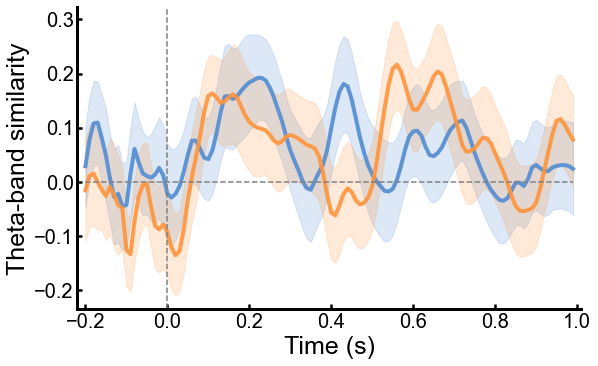

In [129]:
# line_color = ['#E36A65','#5CBBBF','#FF943C']    # 红色湖蓝色 正确快攻击，正确慢攻击 
line_color = ['#538CD2', '#FF943C','#9F79C6','#DA8A97','#6BA147']    # 红色湖蓝色 正确快攻击，正确慢攻击 
# line_color = ['#538CD2', '#E36A65']    # 红色湖蓝色 正确快攻击，正确慢攻击 

# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#E36A65','#FF943C']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#FF943C', '#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6

# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]
# event_2_line_color = line_color[2]

# the number of time axis
times = corr_14_low.times

data_1 = corr_12_low.data
data_2 = corr_14_low.data
# data_3 = corr_14_low.data

plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))
# epoch_mean[2] = np.squeeze(np.average(data_3, axis=0))

# plt.plot(times, np.transpose(data_1[-1]))
# plt.legend(subjects)

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')
# plt.plot(times, epoch_mean[2], color=line_color[2], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[20], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))
# std_event2 = np.squeeze(np.std(data_3, axis=0))


se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])
# se_event2 = std_event2/np.sqrt(data_3.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)
# plt.fill_between(times, epoch_mean[2] - se_event2, epoch_mean[2] + se_event2, color=line_color[2], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
# min_value_3 = np.min(epoch_mean[2] - se_event2)

min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_1_low):
    c = c[0]
    if cluster_p_values_1_low[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
# for i_c, c in enumerate(clusters_2_low):
#     c = c[0]
#     if cluster_p_values_2_low[i_c] <= 0.05:
#         # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
#         plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_3_low):
    c = c[0]
    if cluster_p_values_3_low[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters_low):
    c = c[0]
    if cluster_p_values_low[i_c] <= 0.05:
        
        plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
# plt.legend(['Task 2','Task 4'])
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 17.5])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Theta-band similarity", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

0.09146372209884239 0.09383721025645188 (-0.023243093268580234, 0.9816272947179698, True)


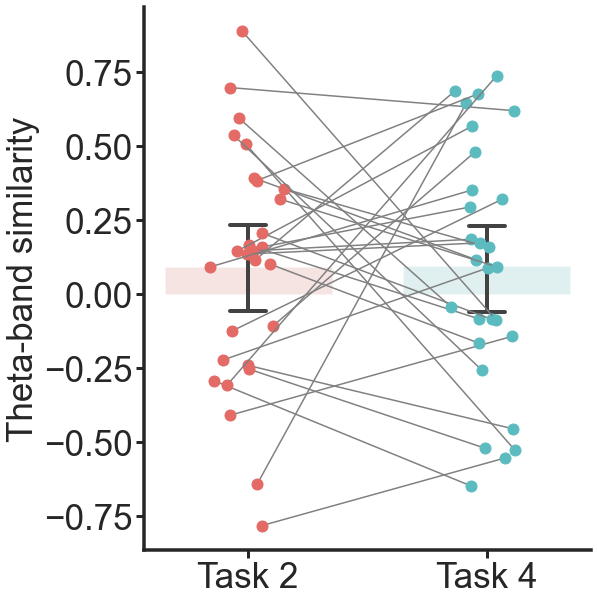

In [109]:
task2_point = np.mean(corr_12_low.data[:, 60:100], axis=1)
task4_point = np.mean(corr_14_low.data[:, 60:100], axis=1)

# 画所有被试的正确率 fast正确率，slow正确率，high_p_avg_get_reward

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
point_color = ['#E36A65', '#5CBBBF']
all_data_df = {}

# 正确率
all_data_df["Task 2"] = np.array(list(task2_point))
all_data_df["Task 4"] = np.array(list(task4_point))
print(np.mean(all_data_df['Task 2']), np.mean(all_data_df['Task 4']), hm_t_test_rel(all_data_df['Task 2'],all_data_df['Task 4']))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Task 2"][i], df_x_jitter["Task 4"][i]], [all_data_df["Task 2"][i], all_data_df["Task 4"][i]], color="grey")
        plt.plot(df_x_jitter["Task 2"][i], all_data_df["Task 2"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Task 4"][i], all_data_df["Task 4"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 3.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    plt.ylabel("Theta-band similarity", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


(array([-0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

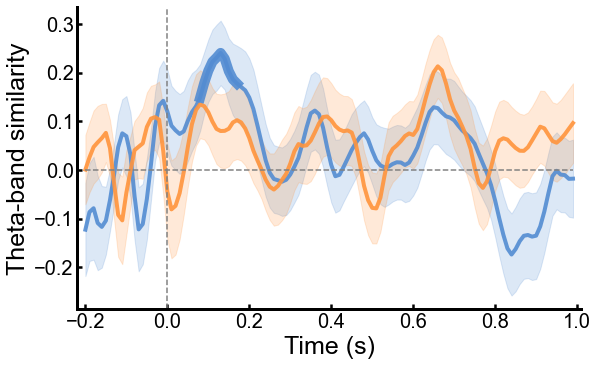

In [130]:
line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
line_color = ['#538CD2', '#FF943C','#9F79C6','#DA8A97','#6BA147']    # 红色湖蓝色 正确快攻击，正确慢攻击 

# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#E36A65','#FF943C']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#FF943C', '#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6

# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]
# event_2_line_color = line_color[2]

# the number of time axis
times = corr_14_high.times

data_1 = corr_12_high.data
data_2 = corr_14_high.data
# data_3 = corr_14_high.data

plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))
# epoch_mean[2] = np.squeeze(np.average(data_3, axis=0))

# plt.plot(times, np.transpose(data_1[-1]))
# plt.legend(subjects)

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')
# plt.plot(times, epoch_mean[2], color=line_color[2], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[20], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))
# std_event2 = np.squeeze(np.std(data_3, axis=0))


se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])
# se_event2 = std_event2/np.sqrt(data_3.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)
# plt.fill_between(times, epoch_mean[2] - se_event2, epoch_mean[2] + se_event2, color=line_color[2], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
# min_value_3 = np.min(epoch_mean[2] - se_event2)

min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_1_high):
    c = c[0]
    if cluster_p_values_1_high[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# # event1 的显著性
# for i_c, c in enumerate(clusters_2_high):
#     c = c[0]
#     if cluster_p_values_2_high[i_c] <= 0.05:
#         # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
#         plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_3_high):
    c = c[0]
    if cluster_p_values_3_high[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# # event 间的显著性
# for i_c, c in enumerate(clusters):
#     c = c[0]
#     if cluster_p_values[i_c] <= 0.05:
        
#         plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
# plt.legend(['Task 2', 'Task 4'])
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 17.5])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Theta-band similarity", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

0.1644190877248562 0.13479757266144346 (0.648605800622531, 0.5220720086090092, True)


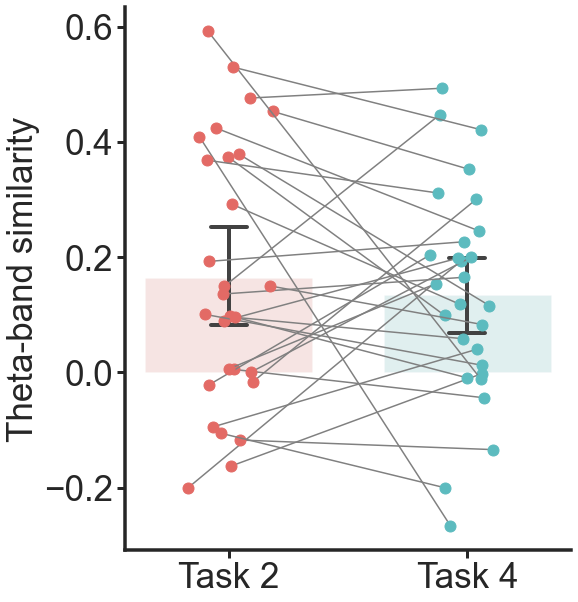

In [150]:
task2_point = np.mean(corr_12_high.data[:, 100:150], axis=1)
task4_point = np.mean(corr_14_high.data[:, 100:150], axis=1)

# 画所有被试的正确率 fast正确率，slow正确率，high_p_avg_get_reward

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
point_color = ['#E36A65', '#5CBBBF']
all_data_df = {}

# 正确率
all_data_df["Task 2"] = np.array(list(task2_point))
all_data_df["Task 4"] = np.array(list(task4_point))
print(np.mean(all_data_df['Task 2']), np.mean(all_data_df['Task 4']), hm_t_test_rel(all_data_df['Task 2'],all_data_df['Task 4']))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Task 2"][i], df_x_jitter["Task 4"][i]], [all_data_df["Task 2"][i], all_data_df["Task 4"][i]], color="grey")
        plt.plot(df_x_jitter["Task 2"][i], all_data_df["Task 2"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Task 4"][i], all_data_df["Task 4"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 3.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    plt.ylabel("Theta-band similarity", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)
